## Evaluación de modelo Pysentimiento

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import os

In [2]:
# Carga de archivo de datos etiquetados por el modelo
ruta_externa = os.path.abspath("../Data")
datos_etiquetados = pd.read_csv(f'{ruta_externa}/Data_Banreservas_Labeled.csv')

# Carga de archivo de datos etiquetados manualmente
datos_etiquetados_humanos = pd.read_excel(f'{ruta_externa}/Sample.xlsx')

In [3]:
# Selección de campos de interés para la comparación
sentimientos_modelo = datos_etiquetados[['Document ID', 'sentimiento']]
sentimientos_humanos = datos_etiquetados_humanos[['Document ID', 'Sentimiento Humano']]

# Combinación de sentimiento detectado por el modelo y sentimiento humano por cada Document ID
comparativa_sentimientos = pd.merge(sentimientos_modelo, sentimientos_humanos, how='inner', on='Document ID')
comparativa_sentimientos.head()

,Document ID,sentimiento,Sentimiento Humano
0,"""1751328518000_loG-g1WPM4vlrqf4kq4jCx--VGoA""",NEU,NEU
1,"""1751318363000_UmSbHhKtvRWX885XVVe5YRpZjK4A""",NEU,POS
2,"""1751305490000_EoGYwn2bhMBIUGfAgWXOsDmEBdUA""",NEU,NEU
3,"""1751256384000__28zvSgoa_xOoMsVV4V8Ezf_Nf8A""",NEU,NEU
4,"""1751044835000_ZYANimsfDiZ2MR45GPjabzGKO8QA""",POS,POS


In [4]:
y_real = comparativa_sentimientos[['Sentimiento Humano']]
y_pred = comparativa_sentimientos[['sentimiento']]

# Matriz de confusión
mc = confusion_matrix(y_real, y_pred)
mc

array([[ 46,  12,   0],
       [ 11, 151,  13],
       [  3,  33, 109]])

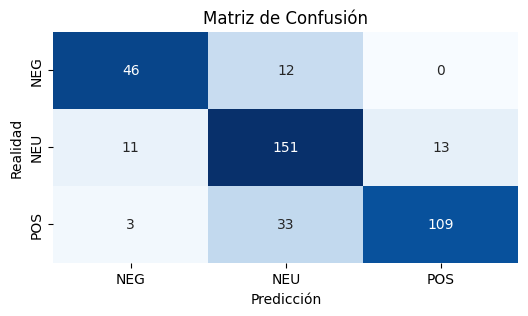

In [5]:
# Normalización de la matriz de confusión
# Convierte cada valor en porcentaje con respecto al total de su fila
# Esto agrega claridad en la distribución de colores del gráfico
cm_normalized = mc.astype('float') / mc.sum(axis=1)[:, np.newaxis]

# La matriz normalizada se usa para el color, los valores de las etiquetas son los originales
plt.figure(figsize=(6, 3))
sns.heatmap(cm_normalized, annot=mc, fmt='d', cmap='Blues',
            xticklabels=['NEG', 'NEU', 'POS'],
            yticklabels=['NEG', 'NEU', 'POS'],
            cbar=False)

plt.ylabel('Realidad')
plt.xlabel('Predicción')
plt.title('Matriz de Confusión')
plt.show()

In [6]:
# Métricas
metricas = classification_report(y_real, y_pred)
print(metricas)

              precision    recall  f1-score   support

         NEG       0.77      0.79      0.78        58
         NEU       0.77      0.86      0.81       175
         POS       0.89      0.75      0.82       145

    accuracy                           0.81       378
   macro avg       0.81      0.80      0.80       378
weighted avg       0.82      0.81      0.81       378

